In [ ]:
from langchain_groq import Chat

In [93]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [94]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("MODEL_NAME")

In [95]:
llm = ChatGroq(
    model=GROQ_MODEL,
    api_key=GROQ_API_KEY,
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)

print("LLM loaded successfully ✅")

LLM loaded successfully ✅


In [96]:
message = [
    {"role": "system", "content": "You are a helpful assistant."},
]
ai_msg = llm.invoke(message)
ai_msg

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The system says I\'m ChatGPT. The developer says "You are a helpful assistant." No special instructions. So I can answer normally. The user hasn\'t asked a question yet. There\'s no user message after developer. The last user message is the system message? Actually the conversation: system, developer, then no user. So I need to respond? Probably need to say hello and ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 76, 'total_tokens': 176, 'completion_time': 0.215638307, 'completion_tokens_details': {'reasoning_tokens': 82}, 'prompt_time': 0.002871734, 'prompt_tokens_details': None, 'queue_time': 0.044387386, 'total_time': 0.218510041}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4c90-8706-7cd2-

In [97]:
ai_msg.content

'Hello! How can I assist you today?'

In [ ]:
from langchain_core.messages import HumanMessage

message = HumanMessage(
    content=[
        {"type": "text", "text": "Describe this image in detail."},
        {
            "type": "image_url",
            "image_url": {"url": "https://example.com/image.jpg"},
        }
    ]
)

response = llm.invoke([message])   # <-- MUST be list
print(response.content)

In [98]:
from langchain.agents import create_agent

In [99]:
from langchain.tools import tool

@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression."""
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"    
    


In [100]:
agent = create_agent(llm,tools=[calculate])

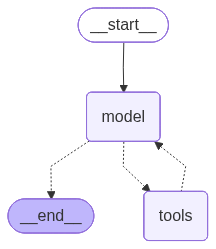

In [101]:
agent

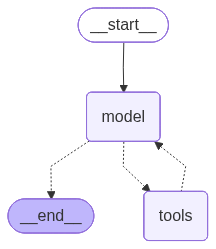

In [102]:
from langchain_core.tools import tool
from langchain.agents import create_agent  # it high level function 
import requests
@tool
def get_post(post_id: int) -> str:
    """
    Fetch a post from JsonPlaceholder by its ID.
    """
    url = f"https://jsonplaceholder.typicode.com/posts/{post_id}"
    response = requests.get(url)
    return response.text 

agent = create_agent(llm, tools=[get_post])
agent



In [103]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "get post with id 5 and summarize it."}
        ]
    }
)

print(response["messages"][-1].content)

**Post Summary (ID 5)**  

- **Title:** *nesciunt quas odio*  
- **Author (User ID):** 1  

**Content Overview:**  
The body consists of four short lines that convey a mix of resignation and reflection:  

1. A sense of rejection or denial (“repudiandae veniam”) paired with a questioning of what is right (“quaerat sunt sed”).  
2. An admission of personal responsibility and effort (“alias aut fugiat sit autem sed est”).  
3. A broader observation about the overwhelming nature of existence (“voluptatem omnis possimus esse voluptatibus quis”).  
4. A concluding note of emotional fatigue or disappointment (“est aut tenetur… dolor neque”).

**Key Themes:**  
- **Conflict & doubt:** The speaker wrestles with what is justified versus what is denied.  
- **Self‑reliance:** Emphasis on personal action despite difficulty.  
- **Overwhelming possibilities:** A feeling that everything is possible yet burdensome.  
- **Emotional weariness:** A lingering sense of unresolved pain.

In short, the pos

In [ ]:
# old Version 
from langchain.agents import create_tool_calling_agent, AgentExecutor

In [104]:
from langchain_core.prompts import ChatPromptTemplate


agent = create_agent(
    model=llm,
    tools=[get_post],
    system_prompt="You are an API assistant. Use tools when needed."
)

response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Get post with id 3 and summarize it."}
        ]
    }
)

print(response["messages"][-1].content)

**Post Summary (ID 3)**  

- **Title:** *“ea molestias quasi exercitationem repellat qui ipsa sit aut”*  
- **Content Overview:** The body consists of four short lines describing a series of actions and feelings:  
  1. A sense of justice (“et iusto sed quo iure”).  
  2. A feeling of overwhelming choice or obligation (“voluptatem occaecati omnis eligendi aut ad”).  
  3. A mix of pain and accusation (“voluptatem doloribus vel accusantium quis pariatur”).  
  4. A concluding note of conflict and personal resolve (“molestiae porro eius odio et labore et velit aut”).  

**In plain language:** The post reflects a conflicted inner dialogue about fairness, overwhelming responsibilities, accusations, and personal struggle, ending with a resolve to confront the difficulties.


<!-- **static Tools** 
Static tools are defined when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach. -->

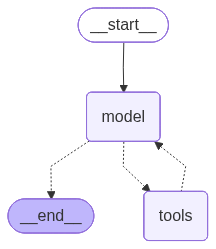

In [105]:
#static Tools 
# Static tools are defined when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.
from langchain.tools import tool
from langchain.agents import create_agent


@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location: str) -> str:
    """Get weather information for a location."""
    return f"Weather in {location}: Sunny, 72°F"

agent = create_agent(llm, tools=[search, get_weather])
agent

<!-- 

Dynamic tools
With dynamic tools, the set of tools available to the agent is modified at runtime rather than defined all upfront. -->

In [106]:
from dataclasses import dataclass

<!-- Dataclass is a Python decorator used to create classes for storing data with automatically generated special methods. 

code when creating classes whose primary purpose is to store structured data

A dataclass in Python is a decorator (@dataclass) used to automatically generate special methods like __init__, __repr__, and __eq__ for classes that are mainly used to store dat -->

In [107]:
@dataclass
class Context:
    user_role: str

<!-- **typing is a module used for type hints**. It provides a way to specify the expected types of variables, function parameters, and return values in Python. This can help improve code readability and catch potential type-related errors during development. -->


In [ ]:
from typing import Callable  #Used when you pass a function as argument.

# def execute(func: Callable[[int, int], int]):
#     return func(5, 10)

# In this example, the execute function takes another function as an argument, which is expected to take two integers and return an integer. The Callable type hint specifies the expected signature of the function being passed in.

In [108]:
from langchain_core.tools import tool

@tool
def read_data() -> str:
    """Read data from system."""
    return "Reading data..."

@tool
def write_data(content: str) -> str:
    """Write data to system."""
    return f"Writing: {content}"

@tool
def delete_data() -> str:
    """Delete data from system."""
    return "Data deleted."

In [109]:
# for middleware in langchain for dynamic tools and function calling 
from langchain.agents.middleware import wrap_model_call, ModelRequest,ModelResponse


In [110]:
@wrap_model_call
def context_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:

    # Get role
    user_role = (
        request.runtime.context.user_role
        if request.runtime and request.runtime.context
        else "viewer"
    )

    # If no tools available, just continue
    if not request.tools:
        return handler(request)

    if user_role == "admin":
        return handler(request)

    elif user_role == "editor":
        tools = [t for t in request.tools if t.name != "delete_data"]
        request = request.override(tools=tools)

    else:
        tools = [t for t in request.tools if t.name.startswith("read_")]
        request = request.override(tools=tools)

    return handler(request)

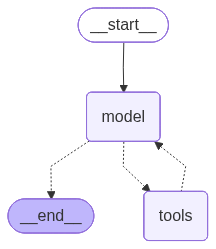

In [111]:
agent = create_agent(
    model = llm,
    tools=[read_data, write_data, delete_data],
middleware=[context_based_tools],
context_schema=Context
)
agent

In [112]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "read data"}
        ]
    },
    config={
        "configurable": {
            "context": Context(user_role="admin")
        }
    }
)

print(response["messages"][-1].content)

I attempted to read the available data, but there doesn’t appear to be any content returned. Could you let me know what specific data you’d like to retrieve or provide more details about where the data is stored? That way I can help you access the information you need.


<!-- This code implements role-based access control for tools in a LangChain agent using middleware. The middleware intercepts the model request, filters tools based on user role stored in runtime context, and ensures secure tool access. -->

<!-- ***System prompt***
You can shape how your agent approaches tasks by providing a prompt. The system_prompt parameter can be provided as a string: -->

In [113]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage

literary_agent = create_agent(
    model=llm,
    system_prompt=SystemMessage(
        content=[
            {
                "type": "text",
                "text": "You are an AI assistant tasked with analyzing literary works.",
            },
            {
                "type": "text",
                "text": "<the entire contents of 'Pride and Prejudice'>",
                "cache_control": {"type": "ephemeral"}
            }
        ]
    )
)

result = literary_agent.invoke(
    {"messages": [HumanMessage("Analyze the major themes in 'Pride and Prejudice'.")]}
)

In [114]:
result = literary_agent.invoke(
    {"messages": [HumanMessage("Analyze the major themes in 'Pride and Prejudice'.")]}
)
print(result)

{'messages': [HumanMessage(content="Analyze the major themes in 'Pride and Prejudice'.", additional_kwargs={}, response_metadata={}, id='dc643b83-cbe5-455a-ae5e-509d049dc20e'), AIMessage(content='**Major Themes in *Pride and Prejudice***  \n\nJane Austen’s *Pride and Prejudice* (1813) is a richly layered novel that, while often celebrated for its sparkling dialogue and memorable characters, works on several deeper thematic levels. Below is an overview of the most prominent themes, how they intersect, and the ways Austen develops them through plot, character, and narrative technique.\n\n---\n\n## 1. Marriage and Social Mobility  \n\n### a. Marriage as an Economic Institution  \n- **Economic necessity vs. romantic love:** For most of the novel’s characters, marriage is the primary means of securing financial stability. The Bennet sisters, especially the younger ones, must marry well to escape the precariousness of their family’s entailment.  \n- **Contrast of motives:**  \n  - **Charlott

In [115]:
result["messages"][-1].content

'**Major Themes in *Pride and Prejudice***  \n\nJane Austen’s *Pride and Prejudice* (1813) is a richly layered novel that, while often celebrated for its sparkling dialogue and memorable characters, works on several deeper thematic levels. Below is an overview of the most prominent themes, how they intersect, and the ways Austen develops them through plot, character, and narrative technique.\n\n---\n\n## 1. Marriage and Social Mobility  \n\n### a. Marriage as an Economic Institution  \n- **Economic necessity vs. romantic love:** For most of the novel’s characters, marriage is the primary means of securing financial stability. The Bennet sisters, especially the younger ones, must marry well to escape the precariousness of their family’s entailment.  \n- **Contrast of motives:**  \n  - **Charlotte Lucas** marries Mr. Collins for security, openly acknowledging that “a woman may be said to be in a state of perpetual danger of being ruined, unless she has a husband.”  \n  - **Elizabeth Benn

<!-- ****Dynamic system prompt****
For more advanced use cases where you need to modify the system prompt based on runtime context or agent state, you can use middleware. -->

In [116]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

result = search_tool.run("Latest AI news 2026")

print(result)

Home AI : Technology, News & Trends Belief and Breakthrough: Outlook on 2026 Artificial Intelligence Development Trends The latest news and reviews on artificial intelligence software, hardware and AI research. ... Apple has acquired Israel-based startup Q. ai , a move ... Boston Consulting Group ’ s January 2026 AI Radar survey found 50% of CEOs believe their jobs depend on successfully implementing AI ... ... in the US, aims to simplify web searches by enhancing conversational capabilities, but it raises concerns about energy use and the impact on news ... News Articles Title: AI Chatbot Grok Faces Global Backlash Over Child Safety Failures Content: Elon Musk ’ s Grok chatbot is under fire after ...


In [117]:
from ddgs import DDGS
from IPython.display import Image, display
query = "Tesla car 2026"

with DDGS() as ddgs:
    results = ddgs.images(query, max_results=5)

    for r in results:
        image_url = r["image"]
        display(Image(url=image_url))

In [118]:
from langchain_community.tools import DuckDuckGoSearchRun 
search_tool = DuckDuckGoSearchRun()

In [119]:
from typing import TypedDict
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

# @tool



agent = create_agent(
    model=llm,
    tools=[search_tool],
    middleware=[user_role_prompt],
    context_schema=Context
)

# The system prompt will be set dynamically based on context
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)
result["messages"][-1].content

'## Machine Learning – A Technical Overview  \n\nMachine learning (ML) is a sub‑field of artificial intelligence (AI) that studies algorithms and statistical models that enable computers to **learn** from data, i.e., to improve their performance on a specific task without being explicitly programmed for every possible situation. In practice, an ML system builds a **function** (often called a *model*) that maps inputs\u202f\\(x\\) to outputs\u202f\\(y\\) by extracting patterns from a collection of examples (the *training data*).\n\nBelow is a structured, technical walk‑through of the main concepts, categories, algorithms, workflow, and current research directions.\n\n---\n\n## 1. Core Formalism  \n\n### 1.1. Problem Setting  \n\n| Element | Symbol | Description |\n|---------|--------|-------------|\n| Input space | \\(\\mathcal{X}\\) | Set of possible feature vectors (e.g., images, text, sensor readings). |\n| Output space | \\(\\mathcal{Y}\\) | Set of target values (e.g., class labels,

<!-- ***Structured output***

**ToolStrategy**

ToolStrategy uses artificial tool calling to generate structured output. This works with any model that supports tool calling. ToolStrategy should be used when provider-native structured output (via ProviderStrategy) is not available or reliable. -->

In [120]:
from pydantic import BaseModel
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy


class ContactInfo(BaseModel):
    name: str
    email: str
    phone: str

agent = create_agent(
    model=llm,
    tools=[search_tool],
    response_format=ToolStrategy(ContactInfo)
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]
# ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

In [123]:
# from pydantic import BaseModel
# from langchain.agents import create_agent
# from langchain.agents.structured_output import ToolStrategy
# from langchain.agents.structured_output import ProviderStrategy
# class Productinfo(BaseModel):
#     name: str
#     price: float
#     description: str

# agent = create_agent(
#     model =llm,
#     tools = [search_tool],
#     response_format=ProviderStrategy(ContactInfo)
# )

# result = agent.invoke(
#     {"messages": [{"role": "user", "content": "Find me a laptop under 75000 INR."}]}
# )

# result['structured_output']

In [124]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langchain_community.tools import DuckDuckGoSearchRun


# 2️⃣ Search Tool
search_tool = DuckDuckGoSearchRun()

# 3️⃣ Schema
class Productinfo(BaseModel):
    name: str
    price: float
    description: str

# 4️⃣ Search First
search_data = search_tool.run(
    "Best laptop under 75000 INR in India with price and description"
)

# 5️⃣ Structured Output
structured_llm = llm.with_structured_output(Productinfo)

response = structured_llm.invoke(f"""
From the search results below, extract ONE laptop under 75000 INR.

Return:
- name
- price (number only)
- description

Search Data:
{search_data}
""")

print(response)

name='Asus TUF Gaming A15 FA566NCR-HN117W' price=0.0 description='Asus TUF Gaming A15 FA566NCR-HN117W Laptop with AMD Octa Core Ryzen 7, 16 GB RAM, 1 TB SSD, suitable for gaming and heavy tasks.'
